# Project 2 - Customer Churn Prediction
### Codveda Business Analytics Internship

**Source datasets:** `churn-bigml-80.csv` for training and `churn-bigml-20.csv` for testing, supplied in the internship dataset package. The project copies may use the names `churn_bigml_80_train.csv` and `churn_bigml_20_test.csv`.

**Tools used:** Python with pandas, numpy, matplotlib and scikit-learn in Jupyter Notebook.

This notebook focuses on the customer-churn classification part of predictive analytics. It compares Logistic Regression, Decision Tree and Random Forest models using the supplied train/test split, then translates the results into customer-retention recommendations.

## 1. Business Problem Definition

Customer churn reduces the number of active customers and can affect recurring revenue. The business goal is to identify customers who are more likely to leave so that retention teams can prioritize follow-up.

**Objective:** predict the `Churn` outcome (True/False) from account and usage information, compare several classification models, and identify the variables most associated with churn.

## 2. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve, classification_report)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9,5)
pd.set_option('display.max_columns', 50)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 3. Dataset Understanding

`churn-bigml-80.csv` is used as the **training set** and `churn-bigml-20.csv` as the **testing set**,
matching the Codveda task instructions.

In [2]:
train = pd.read_csv("../01_Datasets/churn_bigml_80_train.csv")
test = pd.read_csv("../01_Datasets/churn_bigml_20_test.csv")

print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)
print("Combined total rows:", train.shape[0] + test.shape[0])
train.head()


Training set shape: (2666, 20)
Testing set shape: (667, 20)
Combined total rows: 3333


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   float64
 15

**Dataset result:** the training set contains **2,666 rows and 20 columns**, and the testing set contains **667 rows and 20 columns**, for a combined total of **3,333 customer records**. Both files use the same 20-column schema.

## 4. Data Quality Checks

In [4]:
print("Missing values in training set:\n", train.isnull().sum().sum())
print("Missing values in testing set:\n", test.isnull().sum().sum())
print("\nDuplicate rows in training set:", train.duplicated().sum())
print("Duplicate rows in testing set:", test.duplicated().sum())
print("\nDistinct states:", train['State'].nunique())
print("Distinct area codes:", sorted(train['Area code'].unique()))


Missing values in training set:
 0
Missing values in testing set:
 0

Duplicate rows in training set: 0
Duplicate rows in testing set: 0

Distinct states: 51
Distinct area codes: [np.int64(408), np.int64(415), np.int64(510)]


**Data quality result:** there are **0 missing values** and **0 duplicate rows** in both the training and testing sets. The data include 51 states and three area codes (408, 415 and 510).

## 5. Exploratory Data Analysis
### 5.1 Actual Churn Rate

Training set churn rate: 14.55%  (388 churned of 2666)
Testing set churn rate:  14.24%  (95 churned of 667)
Combined churn rate:     14.49%  (483 churned of 3333)


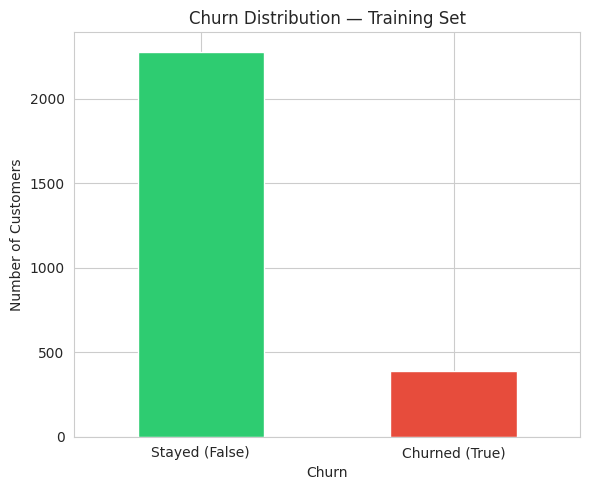

In [5]:
train_churn_rate = train['Churn'].mean() * 100
test_churn_rate = test['Churn'].mean() * 100
combined = pd.concat([train, test])
combined_churn_rate = combined['Churn'].mean() * 100

print(f"Training set churn rate: {train_churn_rate:.2f}%  ({train['Churn'].sum()} churned of {len(train)})")
print(f"Testing set churn rate:  {test_churn_rate:.2f}%  ({test['Churn'].sum()} churned of {len(test)})")
print(f"Combined churn rate:     {combined_churn_rate:.2f}%  ({combined['Churn'].sum()} churned of {len(combined)})")

fig, ax = plt.subplots(figsize=(6,5))
train['Churn'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'], ax=ax)
ax.set_xticklabels(['Stayed (False)','Churned (True)'], rotation=0)
ax.set_title('Churn Distribution - Training Set')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project2/churn_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


**Churn result:** the training churn rate is **14.55%** (388 of 2,666), the testing churn rate is **14.24%** (95 of 667), and the combined churn rate is **14.49%** (483 of 3,333). Because churn is the minority class, model evaluation should use Precision, Recall, F1-score and ROC-AUC in addition to Accuracy.

### 5.2 Variables Associated with Churn

In [6]:
cat_vars = ['International plan', 'Voice mail plan']
for col in cat_vars:
    print(f"--- Churn rate by {col} ---")
    print((train.groupby(col)['Churn'].mean()*100).round(2))
    print()


--- Churn rate by International plan ---
International plan
No     11.27
Yes    43.70
Name: Churn, dtype: float64

--- Churn rate by Voice mail plan ---


Voice mail plan
No     16.71
Yes     8.87
Name: Churn, dtype: float64



**Plan comparison:** customers with an International plan have a churn rate of **43.70%**, compared with **11.27%** for customers without it. Customers without a Voice mail plan have a churn rate of **16.71%**, compared with **8.87%** for customers with the plan. These are associations in the training data and should not be interpreted as causal effects.

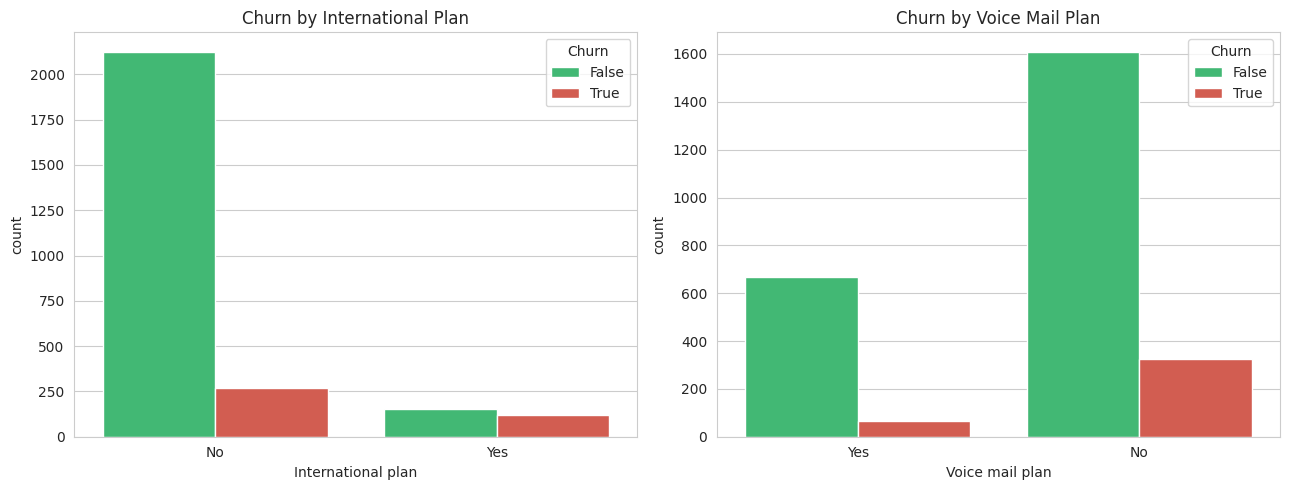

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.countplot(data=train, x='International plan', hue='Churn', ax=axes[0], palette=['#2ecc71','#e74c3c'])
axes[0].set_title('Churn by International Plan')
sns.countplot(data=train, x='Voice mail plan', hue='Churn', ax=axes[1], palette=['#2ecc71','#e74c3c'])
axes[1].set_title('Churn by Voice Mail Plan')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project2/churn_by_plan.png', dpi=120, bbox_inches='tight')
plt.show()


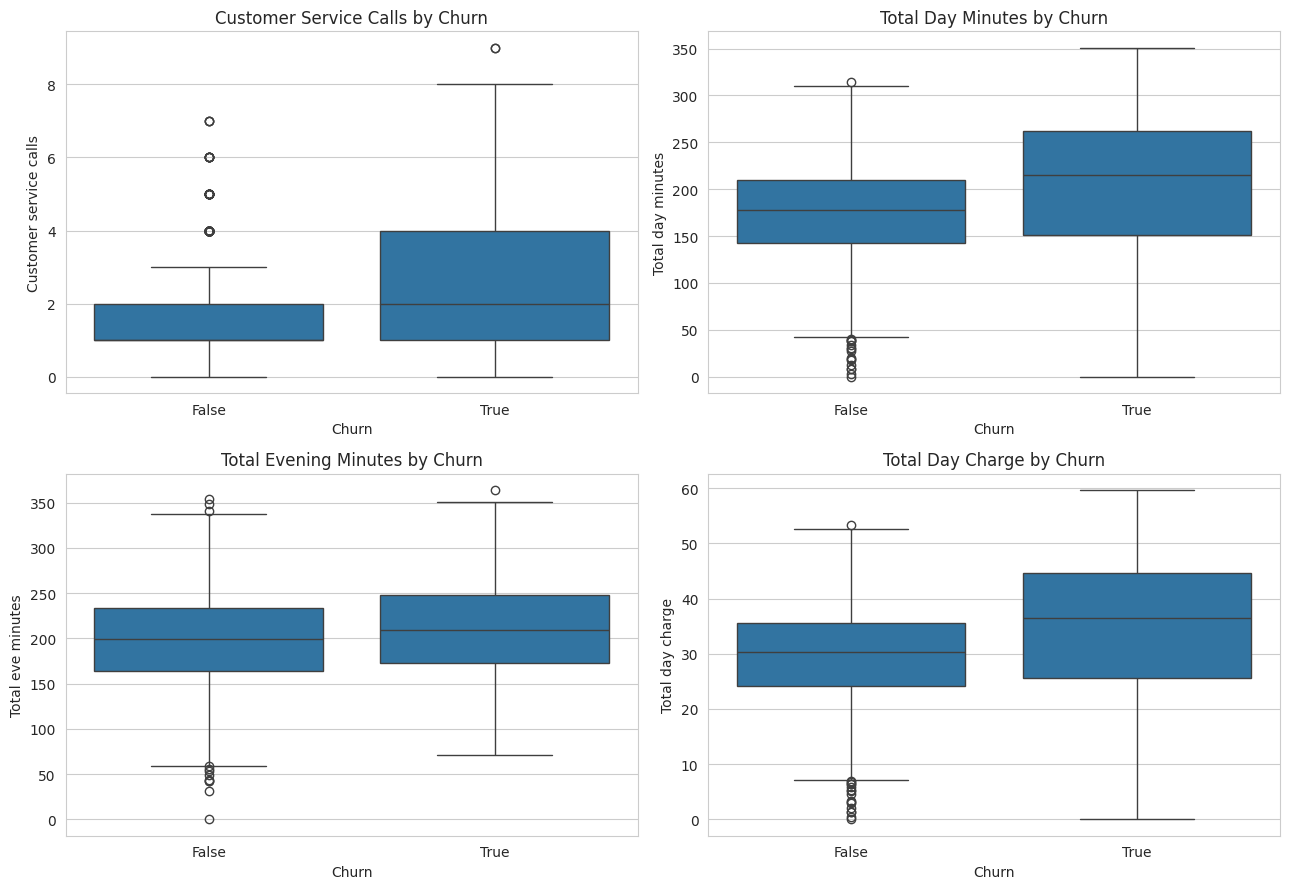

Avg Customer Service Calls — Churned: 2.21  | Stayed: 1.45
Avg Total Day Minutes — Churned: 205.18  | Stayed: 175.1


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13,9))
sns.boxplot(data=train, x='Churn', y='Customer service calls', ax=axes[0,0])
axes[0,0].set_title('Customer Service Calls by Churn')
sns.boxplot(data=train, x='Churn', y='Total day minutes', ax=axes[0,1])
axes[0,1].set_title('Total Day Minutes by Churn')
sns.boxplot(data=train, x='Churn', y='Total eve minutes', ax=axes[1,0])
axes[1,0].set_title('Total Evening Minutes by Churn')
sns.boxplot(data=train, x='Churn', y='Total day charge', ax=axes[1,1])
axes[1,1].set_title('Total Day Charge by Churn')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project2/churn_by_usage.png', dpi=120, bbox_inches='tight')
plt.show()

print("Avg Customer Service Calls - Churned:", train[train['Churn']]['Customer service calls'].mean().round(2),
      " | Stayed:", train[~train['Churn']]['Customer service calls'].mean().round(2))
print("Avg Total Day Minutes - Churned:", train[train['Churn']]['Total day minutes'].mean().round(2),
      " | Stayed:", train[~train['Churn']]['Total day minutes'].mean().round(2))


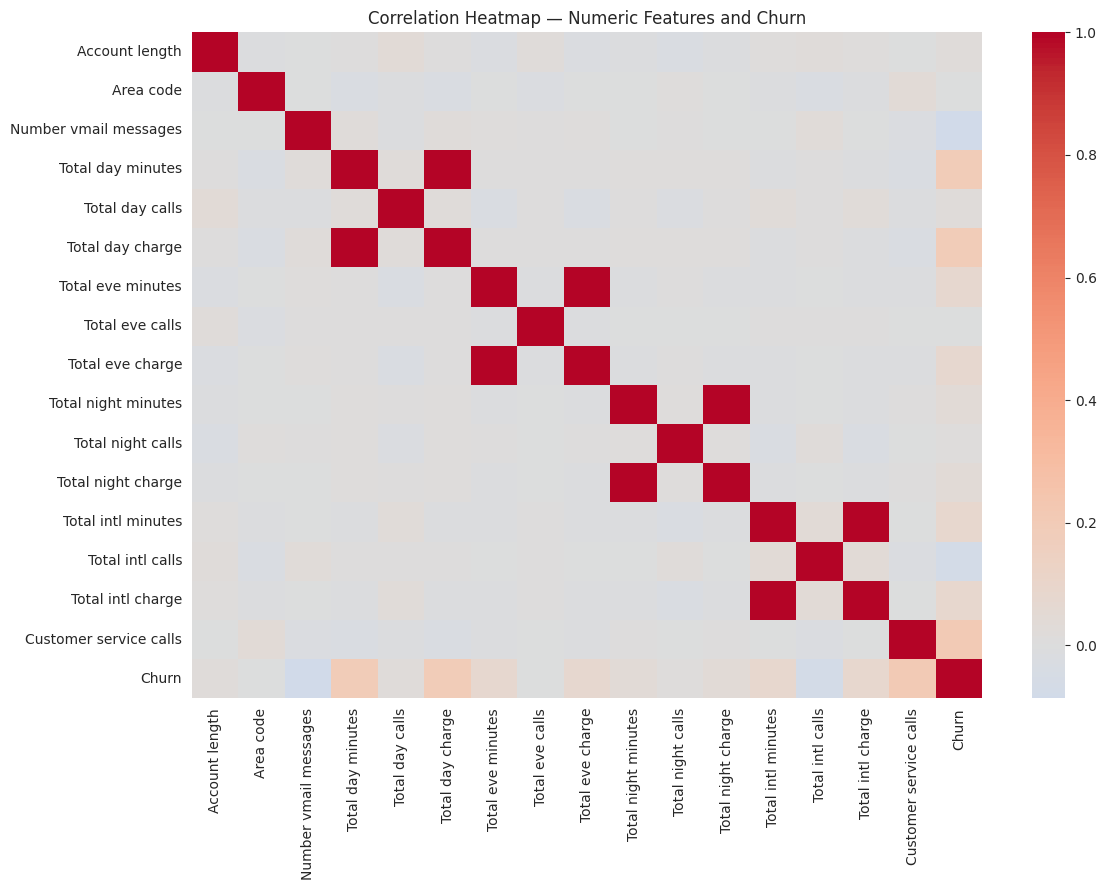

Top correlations with Churn:
Churn                     1.000000
Customer service calls    0.202590
Total day charge          0.195689
Total day minutes         0.195688
Total intl charge         0.086216
Total intl minutes        0.086204
Total eve minutes         0.072906
Total eve charge          0.072893
Total night minutes       0.033639
Total night charge        0.033635
Total day calls           0.018290
Account length            0.017728
Total night calls         0.012262
Area code                 0.001019
Total eve calls          -0.001539
Total intl calls         -0.069882
Number vmail messages    -0.086474
Name: Churn, dtype: float64


In [9]:
corr_data = train.select_dtypes(include=[np.number]).copy()
corr_data['Churn'] = train['Churn'].astype(int)
plt.figure(figsize=(12,9))
sns.heatmap(corr_data.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap - Numeric Features and Churn')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project2/correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top correlations with Churn:")
print(corr_data.corr()['Churn'].sort_values(ascending=False))


## 6. Data Preprocessing

Steps performed:
1. Encode `International plan` and `Voice mail plan` as 0/1.
2. Encode `State` as a numeric category for this model comparison.
3. Convert `Churn` from True/False to 1/0.
4. Exclude `Area code` from the model feature set because it is a location code rather than an ordered numeric measure.
5. Standardize the predictors for Logistic Regression only. Tree-based models use the unscaled values.
6. Keep the supplied 80/20 train/test split rather than creating a new random split.

In [10]:
def preprocess(df):
    d = df.copy()
    d['International plan'] = d['International plan'].map({'Yes':1, 'No':0})
    d['Voice mail plan'] = d['Voice mail plan'].map({'Yes':1, 'No':0})
    d['Churn'] = d['Churn'].astype(int)
    return d

train_p = preprocess(train)
test_p = preprocess(test)

# Label-encode State using the training data only.
state_encoder = LabelEncoder()
state_encoder.fit(train_p['State'])
train_p['State_encoded'] = state_encoder.transform(train_p['State'])
test_p['State_encoded'] = state_encoder.transform(test_p['State'])

feature_cols = ['State_encoded', 'Account length', 'International plan', 'Voice mail plan',
                'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge',
                'Total eve minutes', 'Total eve calls', 'Total eve charge',
                'Total night minutes', 'Total night calls', 'Total night charge',
                'Total intl minutes', 'Total intl calls', 'Total intl charge',
                'Customer service calls']

X_train = train_p[feature_cols]
y_train = train_p['Churn']
X_test = test_p[feature_cols]
y_test = test_p['Churn']

print("X_train shape:", X_train.shape, " y_train churn rate:", y_train.mean().round(4))
print("X_test shape:", X_test.shape, " y_test churn rate:", y_test.mean().round(4))


X_train shape: (2666, 18)  y_train churn rate: 0.1455
X_test shape: (667, 18)  y_test churn rate: 0.1424


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete - used for Logistic Regression only.")


Scaling complete — used for Logistic Regression only.


## 7. Model 1 - Logistic Regression

In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:,1]

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"Logistic Regression - Accuracy: {acc_lr:.4f}, Precision: {prec_lr:.4f}, Recall: {rec_lr:.4f}, F1: {f1_lr:.4f}, ROC-AUC: {auc_lr:.4f}")
print()
print(confusion_matrix(y_test, y_pred_lr))


Logistic Regression — Accuracy: 0.8546, Precision: 0.4737, Recall: 0.1895, F1: 0.2707, ROC-AUC: 0.8265

[[552  20]
 [ 77  18]]


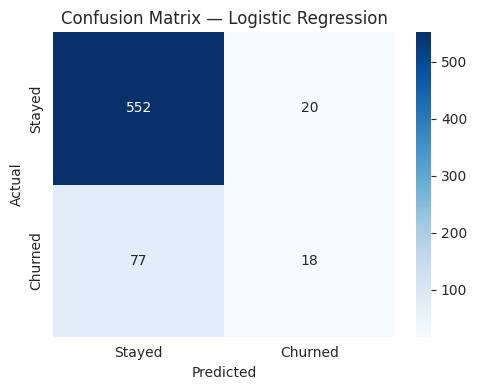

In [13]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Stayed','Churned'], yticklabels=['Stayed','Churned'])
ax.set_title('Confusion Matrix - Logistic Regression')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project2/cm_logistic_regression.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. Model 2 - Decision Tree

In [14]:
dtree = DecisionTreeClassifier(max_depth=6, random_state=42)
dtree.fit(X_train, y_train)

y_pred_dt = dtree.predict(X_test)
y_proba_dt = dtree.predict_proba(X_test)[:,1]

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)

print(f"Decision Tree - Accuracy: {acc_dt:.4f}, Precision: {prec_dt:.4f}, Recall: {rec_dt:.4f}, F1: {f1_dt:.4f}, ROC-AUC: {auc_dt:.4f}")
print()
print(confusion_matrix(y_test, y_pred_dt))


Decision Tree — Accuracy: 0.9535, Precision: 0.8810, Recall: 0.7789, F1: 0.8268, ROC-AUC: 0.8799

[[562  10]
 [ 21  74]]


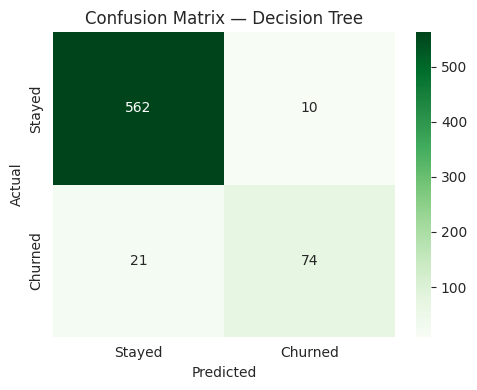

In [15]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Stayed','Churned'], yticklabels=['Stayed','Churned'])
ax.set_title('Confusion Matrix - Decision Tree')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project2/cm_decision_tree.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. Model 3 - Random Forest

In [16]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"Random Forest - Accuracy: {acc_rf:.4f}, Precision: {prec_rf:.4f}, Recall: {rec_rf:.4f}, F1: {f1_rf:.4f}, ROC-AUC: {auc_rf:.4f}")
print()
print(confusion_matrix(y_test, y_pred_rf))


Random Forest — Accuracy: 0.9490, Precision: 0.9296, Recall: 0.6947, F1: 0.7952, ROC-AUC: 0.9266

[[567   5]
 [ 29  66]]


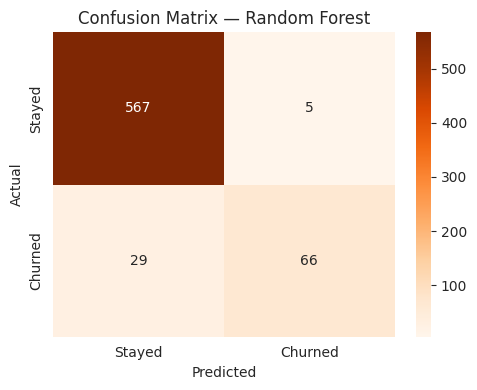

In [17]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Stayed','Churned'], yticklabels=['Stayed','Churned'])
ax.set_title('Confusion Matrix - Random Forest')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project2/cm_random_forest.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. Model Comparison

In [18]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [acc_lr, acc_dt, acc_rf],
    'Precision': [prec_lr, prec_dt, prec_rf],
    'Recall': [rec_lr, rec_dt, rec_rf],
    'F1-Score': [f1_lr, f1_dt, f1_rf],
    'ROC-AUC': [auc_lr, auc_dt, auc_rf],
}).round(4)
results


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8546,0.4737,0.1895,0.2707,0.8265
1,Decision Tree,0.9535,0.8810,0.7789,0.8268,0.8799
2,Random Forest,0.9490,0.9296,0.6947,0.7952,0.9266


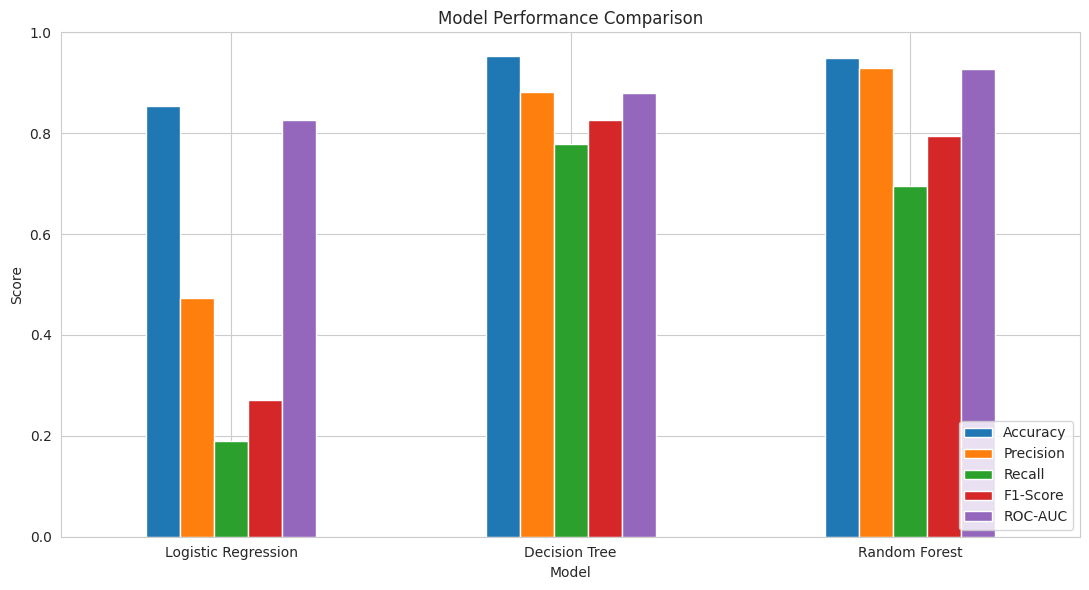

In [19]:
fig, ax = plt.subplots(figsize=(11,6))
results.set_index('Model')[['Accuracy','Precision','Recall','F1-Score','ROC-AUC']].plot(kind='bar', ax=ax)
ax.set_title('Model Performance Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0,1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../06_Reports/charts_project2/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


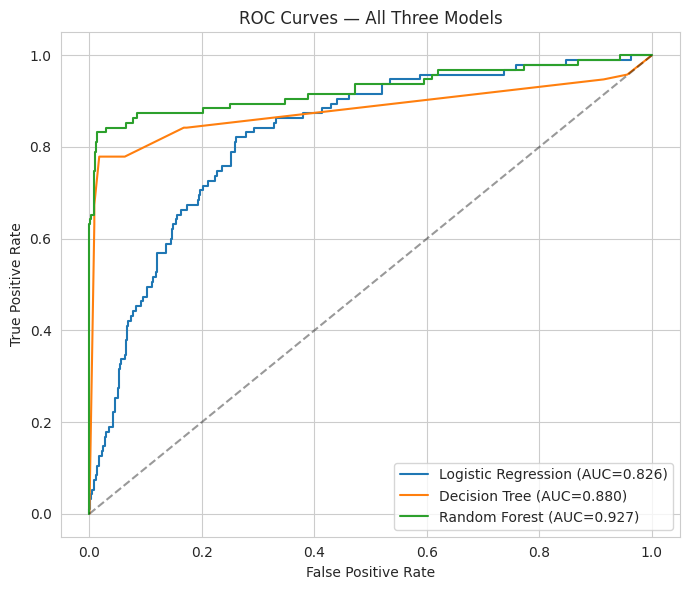

In [20]:
fig, ax = plt.subplots(figsize=(7,6))
for name, proba in [('Logistic Regression', y_proba_lr), ('Decision Tree', y_proba_dt), ('Random Forest', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - All Three Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project2/roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()


In [21]:
best_model_row = results.loc[results['F1-Score'].idxmax()]
print("Best-performing model based on F1-Score (balances Precision and Recall, appropriate given the")
print("14.55% churn imbalance):")
print(best_model_row)


Best-performing model based on F1-Score (balances Precision and Recall, appropriate given the
14.55% churn imbalance):
Model        Decision Tree
Accuracy            0.9535
Precision            0.881
Recall              0.7789
F1-Score            0.8268
ROC-AUC             0.8799
Name: 1, dtype: object


**Model comparison:**
- Logistic Regression: Accuracy 0.8546, Precision 0.4737, Recall 0.1895, F1 0.2707, ROC-AUC 0.8265.
- Decision Tree: Accuracy 0.9535, Precision 0.8810, Recall 0.7789, F1 0.8268, ROC-AUC 0.8799.
- Random Forest: Accuracy 0.9490, Precision 0.9296, Recall 0.6947, F1 0.7952, ROC-AUC 0.9266.

The **Decision Tree** is selected for the retention use case because it has the highest F1-score and higher Recall than Random Forest. Random Forest has the highest Precision and ROC-AUC, so it remains a useful alternative when reducing false-positive retention contacts is more important.

## 11. Feature Importance

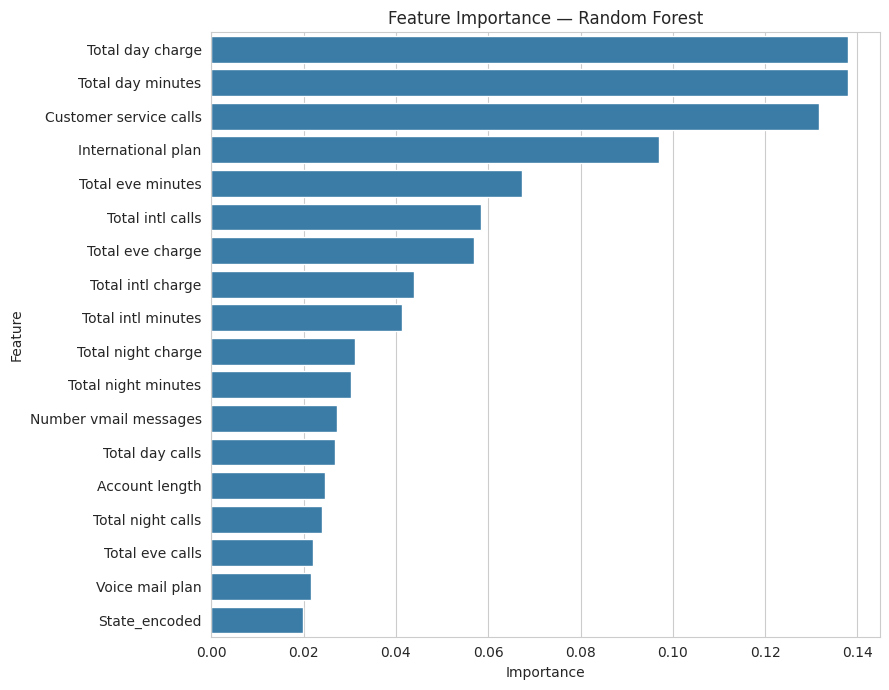

,Feature,Importance
7,Total day charge,0.137993
5,Total day minutes,0.137950
17,Customer service calls,0.131606
2,International plan,0.096924
8,Total eve minutes,0.067272
15,Total intl calls,0.058500
10,Total eve charge,0.056917
16,Total intl charge,0.043886
14,Total intl minutes,0.041409
13,Total night charge,0.031053


In [22]:
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9,7))
sns.barplot(data=rf_importance, y='Feature', x='Importance', ax=ax, color='#2980b9')
ax.set_title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project2/feature_importance_rf.png', dpi=120, bbox_inches='tight')
plt.show()

rf_importance


In [23]:
lr_coef = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print("Logistic Regression coefficients (standardized features, sign shows direction of effect):")
lr_coef


Logistic Regression coefficients (standardized features, sign shows direction of effect):


,Feature,Coefficient
3,Voice mail plan,-0.805145
17,Customer service calls,0.662191
2,International plan,0.629676
4,Number vmail messages,0.412630
7,Total day charge,0.340548
5,Total day minutes,0.340459
15,Total intl calls,-0.292489
8,Total eve minutes,0.144070
10,Total eve charge,0.142678
16,Total intl charge,0.142524


**Feature importance result:** the leading Random Forest features are Total day charge (0.138), Total day minutes (0.138), Customer service calls (0.132), and International plan (0.097). Logistic Regression also gives positive coefficients for Customer service calls and International plan. These model signals are useful for prioritization, but they should not be interpreted as proof of causation.

## 12. Business Interpretation

- Combined churn is 14.49%, or 483 of 3,333 customers.
- International plan customers have a much higher observed churn rate (43.70%) than customers without the plan (11.27%).
- Voice mail plan customers have a lower observed churn rate (8.87%) than customers without it (16.71%).
- Churned customers average 2.21 customer service calls compared with 1.45 among customers who stayed.
- Churned customers average 205.18 total day minutes compared with 175.10 among customers who stayed.
- On the test set, the Decision Tree identifies 77.89% of actual churners and has 88.10% Precision.

## 13. Customer-Retention Recommendations

- Review the International plan segment because its churn rate is much higher in this dataset.
- Use repeated customer service calls as an early-warning signal for retention follow-up.
- Consider the Voice mail plan association as a segmentation signal, but validate the reason before changing product or pricing strategy.
- Use the Decision Tree as the primary monthly churn-risk scoring model for this analysis, with Random Forest as a higher-precision comparison model.
- Re-evaluate model performance regularly when newer customer data become available.

## 14. Limitations

- The 3,333 records are a supplied historical dataset, so performance may differ on another customer base.
- Churn is imbalanced at 14.49%, which is why Accuracy is not used alone.
- The analysis identifies associations and predictive patterns, not causal effects.
- State is label-encoded for this comparison; one-hot encoding or another categorical treatment could be tested in a future model iteration.
- The results depend on the supplied 80/20 split and should be validated on newer operational data before deployment.

## 15. Conclusion

The analysis uses 2,666 training records and 667 test records to compare three churn classification models. The Decision Tree gives the best F1-score (0.8268), while Random Forest gives the highest ROC-AUC (0.9266) and Precision (0.9296). International plan status, customer service calls and day-time usage are important predictive signals in this dataset. These results support targeted retention prioritization while recognizing that model performance should be rechecked on newer business data.